Google Drive is already mounted.
Human-labeled training data:
label
back_kick          95
side_kick          85
axe_kick           84
front_kick         82
roundhouse_kick    79
Name: count, dtype: int64
Total: 425

Feature dataset shape: (425, 1241)
label
back_kick          95
side_kick          85
axe_kick           84
front_kick         82
roundhouse_kick    79
Name: count, dtype: int64
Saved feature dataset: /content/drive/MyDrive/taekwondo_model_outputs_human_labeled_v2/taekwondo_human_labeled_feature_dataset.csv

Classes: ['axe_kick', 'back_kick', 'front_kick', 'roundhouse_kick', 'side_kick']
Minimum class count: 79

Using Stratified 5-Fold Cross Validation

Evaluation type: 5-fold human-labeled cross validation
Human-labeled validation accuracy: 0.9035294117647059

                 precision    recall  f1-score   support

       axe_kick       0.91      0.89      0.90        84
      back_kick       0.95      0.92      0.93        95
     front_kick       0.86      0.89      0.8

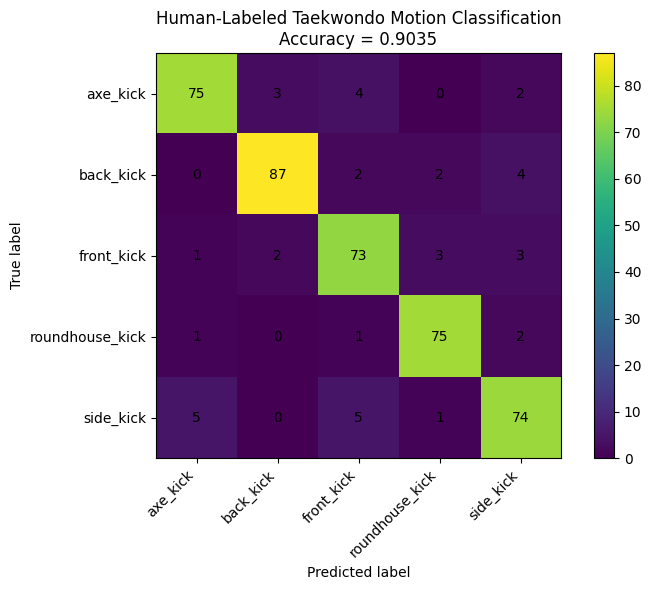

Saved confusion matrix: /content/drive/MyDrive/taekwondo_model_outputs_human_labeled_v2/taekwondo_confusion_matrix.png

Model artifacts saved:
/content/drive/MyDrive/taekwondo_model_outputs_human_labeled_v2/taekwondo_motion_classifier_random_forest.joblib
/content/drive/MyDrive/taekwondo_model_outputs_human_labeled_v2/taekwondo_label_encoder.joblib
/content/drive/MyDrive/taekwondo_model_outputs_human_labeled_v2/taekwondo_feature_columns.json
/content/drive/MyDrive/taekwondo_model_outputs_human_labeled_v2/taekwondo_model_summary.json
/content/drive/MyDrive/taekwondo_model_outputs_human_labeled_v2/taekwondo_confusion_matrix.png

DONE. Human-labeled v2 model is ready.
{
  "model_version": "human-labeled-v2",
  "label_source": "manual human labels",
  "evaluation_type": "5-fold human-labeled cross validation",
  "accuracy": 0.9035294117647059,
  "accuracy_note": "This accuracy is based on manually labeled validation data.",
  "num_samples": 425,
  "num_classes": 5,
  "classes": [
    "axe_

In [ ]:
import os

if os.path.exists("/content/drive/MyDrive"):
    print("Google Drive is already mounted.")
else:
    from google.colab import drive
    drive.mount("/content/drive")

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


LABEL_PATH = "/content/drive/MyDrive/taekwondo_manual_labels_all_batches.csv"
OUT_DIR = Path("/content/drive/MyDrive/taekwondo_model_outputs_human_labeled_v2")
OUT_DIR.mkdir(parents=True, exist_ok=True)

valid_training_labels = [
    "front_kick",
    "roundhouse_kick",
    "side_kick",
    "axe_kick",
    "back_kick",
]


def extract_features_from_keypoints(csv_path):
    df = pd.read_csv(csv_path)

    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
    numeric_df = numeric_df.interpolate(limit_direction="both")
    numeric_df = numeric_df.fillna(0)

    features = {}
    features["n_frames"] = len(numeric_df)
    features["n_numeric_cols"] = numeric_df.shape[1]

    for col in numeric_df.columns:
        s = numeric_df[col].astype(float)

        features[f"{col}_mean"] = s.mean()
        features[f"{col}_std"] = s.std()
        features[f"{col}_min"] = s.min()
        features[f"{col}_max"] = s.max()
        features[f"{col}_range"] = s.max() - s.min()
        features[f"{col}_median"] = s.median()

        motion = s.diff().fillna(0).abs()
        features[f"{col}_motion_mean"] = motion.mean()
        features[f"{col}_motion_max"] = motion.max()
        features[f"{col}_motion_std"] = motion.std()

    body_pairs = [
        ("right_foot_index_x", "right_foot_index_y"),
        ("left_foot_index_x", "left_foot_index_y"),
        ("right_ankle_x", "right_ankle_y"),
        ("left_ankle_x", "left_ankle_y"),
        ("right_knee_x", "right_knee_y"),
        ("left_knee_x", "left_knee_y"),
        ("right_wrist_x", "right_wrist_y"),
        ("left_wrist_x", "left_wrist_y"),
        ("right_hip_x", "right_hip_y"),
        ("left_hip_x", "left_hip_y"),
    ]

    for x_col, y_col in body_pairs:
        if x_col in numeric_df.columns and y_col in numeric_df.columns:
            dx = numeric_df[x_col].diff().fillna(0)
            dy = numeric_df[y_col].diff().fillna(0)
            speed = np.sqrt(dx**2 + dy**2)

            part = x_col.replace("_x", "")
            features[f"{part}_speed_mean"] = speed.mean()
            features[f"{part}_speed_max"] = speed.max()
            features[f"{part}_speed_std"] = speed.std()
            features[f"{part}_x_range"] = numeric_df[x_col].max() - numeric_df[x_col].min()
            features[f"{part}_y_range"] = numeric_df[y_col].max() - numeric_df[y_col].min()

    return features


# 1. Load manual labels
df_label = pd.read_csv(LABEL_PATH)

df_train_list = df_label[
    (df_label["label_status"] == "labeled") &
    (df_label["manual_label"].isin(valid_training_labels))
].copy()

df_train_list["label"] = df_train_list["manual_label"]

print("Human-labeled training data:")
print(df_train_list["label"].value_counts())
print("Total:", len(df_train_list))

if len(df_train_list) < 20:
    raise ValueError("Too few labeled samples. Please label more videos before training.")


# 2. Extract features
rows = []

for i, row in df_train_list.iterrows():
    csv_path = row["csv_path"]

    if not isinstance(csv_path, str) or not os.path.exists(csv_path):
        print("Missing CSV:", csv_path)
        continue

    try:
        features = extract_features_from_keypoints(csv_path)
        features["video_name"] = row["video_name"]
        features["csv_path"] = csv_path
        features["label"] = row["label"]
        rows.append(features)
    except Exception as e:
        print("Failed:", row["video_name"], e)

df_features = pd.DataFrame(rows)

print("\nFeature dataset shape:", df_features.shape)
print(df_features["label"].value_counts())

feature_path = OUT_DIR / "taekwondo_human_labeled_feature_dataset.csv"
df_features.to_csv(feature_path, index=False, encoding="utf-8-sig")
print("Saved feature dataset:", feature_path)


# 3. Prepare X / y
meta_cols = ["video_name", "csv_path", "label"]
feature_columns = [c for c in df_features.columns if c not in meta_cols]

X = df_features[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df_features["label"]

encoder = LabelEncoder()
y_enc = encoder.fit_transform(y)

min_class_count = y.value_counts().min()
n_classes = y.nunique()

print("\nClasses:", list(encoder.classes_))
print("Minimum class count:", min_class_count)


# 4. Model
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)


# 5. Evaluation
if min_class_count >= 2:
    n_splits = min(5, min_class_count)

    print(f"\nUsing Stratified {n_splits}-Fold Cross Validation")

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    y_pred_enc = cross_val_predict(model, X, y_enc, cv=cv)
    evaluation_type = f"{n_splits}-fold human-labeled cross validation"
else:
    print("\nWARNING: Some classes have only 1 sample. Using training accuracy only.")
    model.fit(X, y_enc)
    y_pred_enc = model.predict(X)
    evaluation_type = "training accuracy only"

accuracy = accuracy_score(y_enc, y_pred_enc)
y_pred = encoder.inverse_transform(y_pred_enc)

print("\n==============================")
print("Evaluation type:", evaluation_type)
print("Human-labeled validation accuracy:", accuracy)
print("==============================\n")

report = classification_report(
    y,
    y_pred,
    labels=list(encoder.classes_),
    zero_division=0
)

print(report)


# 6. Save predictions
df_predictions = df_features[["video_name", "csv_path", "label"]].copy()
df_predictions["predicted_label"] = y_pred
df_predictions["correct"] = df_predictions["label"] == df_predictions["predicted_label"]

prediction_path = OUT_DIR / "taekwondo_per_video_predictions.csv"
df_predictions.to_csv(prediction_path, index=False, encoding="utf-8-sig")
print("Saved predictions:", prediction_path)


# 7. Confusion matrix
cm = confusion_matrix(
    y,
    y_pred,
    labels=list(encoder.classes_)
)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Human-Labeled Taekwondo Motion Classification\nAccuracy = {accuracy:.4f}")
plt.colorbar()

tick_marks = np.arange(len(encoder.classes_))
plt.xticks(tick_marks, encoder.classes_, rotation=45, ha="right")
plt.yticks(tick_marks, encoder.classes_)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()

cm_path = OUT_DIR / "taekwondo_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved confusion matrix:", cm_path)


# 8. Train final model on all human-labeled data
model.fit(X, y_enc)

model_path = OUT_DIR / "taekwondo_motion_classifier_random_forest.joblib"
encoder_path = OUT_DIR / "taekwondo_label_encoder.joblib"
feature_columns_path = OUT_DIR / "taekwondo_feature_columns.json"
summary_path = OUT_DIR / "taekwondo_model_summary.json"

joblib.dump(model, model_path)
joblib.dump(encoder, encoder_path)

with open(feature_columns_path, "w") as f:
    json.dump(feature_columns, f, indent=2)

summary = {
    "model_version": "human-labeled-v2",
    "label_source": "manual human labels",
    "evaluation_type": evaluation_type,
    "accuracy": float(accuracy),
    "accuracy_note": "This accuracy is based on manually labeled validation data.",
    "num_samples": int(len(df_features)),
    "num_classes": int(n_classes),
    "classes": list(encoder.classes_),
    "class_distribution": y.value_counts().to_dict(),
    "feature_count": int(len(feature_columns)),
    "model_path": str(model_path),
    "prediction_path": str(prediction_path),
    "confusion_matrix_path": str(cm_path),
}

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\nModel artifacts saved:")
print(model_path)
print(encoder_path)
print(feature_columns_path)
print(summary_path)
print(cm_path)

print("\nDONE. Human-labeled v2 model is ready.")
print(json.dumps(summary, indent=2))

In [ ]:
import os
import glob
import pandas as pd

ROOT = "/content/drive/MyDrive"

print("Drive mounted:", os.path.exists(ROOT))
print("Listing MyDrive top-level files/folders:")
print(os.listdir(ROOT)[:50])

patterns = [
    "/content/drive/MyDrive/**/taekwondo_manual_labels*.csv",
    "/content/drive/MyDrive/**/taekwondo_manual_labeling*.csv",
    "/content/drive/MyDrive/**/manual_labels*.csv",
]

found = []

for pattern in patterns:
    files = glob.glob(pattern, recursive=True)
    found.extend(files)

found = sorted(set(found))

print("\nFound files:", len(found))

for f in found:
    print(f)

Drive mounted: True
Listing MyDrive top-level files/folders:
['taekwondo_model_outputs_human_labeled_v3']

Found files: 0


In [ ]:
import os
import glob
import pandas as pd

ROOT = "/content/drive/MyDrive"

print("Drive mounted:", os.path.exists(ROOT))

files = sorted(glob.glob(f"{ROOT}/taekwondo_manual_labels*.csv"))

print("Matched files:", len(files))

for f in files:
    print(f)

Drive mounted: True
Matched files: 0


In [ ]:
from google.colab import drive
import os
import glob
import pandas as pd

MOUNT_POINT = "/content/google_drive_jason"

drive.mount(MOUNT_POINT, force_remount=True)

ROOT = f"{MOUNT_POINT}/MyDrive"

print("ROOT:", ROOT)
print("ROOT exists:", os.path.exists(ROOT))

files = sorted(glob.glob(f"{ROOT}/taekwondo_manual_labels*.csv"))

print("\nMatched label files:", len(files))
for f in files:
    print(f)

LABEL_TRAIN_PATH = f"{ROOT}/taekwondo_manual_labels_training_valid.csv"

print("\nTraining valid exists:", os.path.exists(LABEL_TRAIN_PATH))
print("Training valid path:", LABEL_TRAIN_PATH)

if not os.path.exists(LABEL_TRAIN_PATH):
    raise FileNotFoundError(
        "Still cannot find taekwondo_manual_labels_training_valid.csv. "
        "You probably selected the wrong Google account during Drive authorization."
    )

df_check = pd.read_csv(LABEL_TRAIN_PATH)

print("\nRows:", len(df_check))
print(df_check["manual_label"].value_counts())

Mounted at /content/google_drive_jason
ROOT: /content/google_drive_jason/MyDrive
ROOT exists: True

Matched label files: 8
/content/google_drive_jason/MyDrive/taekwondo_manual_labels.csv
/content/google_drive_jason/MyDrive/taekwondo_manual_labels_all_batches.csv
/content/google_drive_jason/MyDrive/taekwondo_manual_labels_batch2.csv
/content/google_drive_jason/MyDrive/taekwondo_manual_labels_batch3.csv
/content/google_drive_jason/MyDrive/taekwondo_manual_labels_batch4.csv
/content/google_drive_jason/MyDrive/taekwondo_manual_labels_batch5.csv
/content/google_drive_jason/MyDrive/taekwondo_manual_labels_before_recover_skipped.csv
/content/google_drive_jason/MyDrive/taekwondo_manual_labels_training_valid.csv

Training valid exists: True
Training valid path: /content/google_drive_jason/MyDrive/taekwondo_manual_labels_training_valid.csv

Rows: 480
manual_label
axe_kick           99
side_kick          98
back_kick          96
roundhouse_kick    95
front_kick         92
Name: count, dtype: int6

Training label file: /content/google_drive_jason/MyDrive/taekwondo_manual_labels_training_valid.csv
Output folder: /content/google_drive_jason/MyDrive/taekwondo_model_outputs_human_labeled_v3
Loaded training labels: (480, 29)

Label distribution:
manual_label
axe_kick           99
side_kick          98
back_kick          96
roundhouse_kick    95
front_kick         92
Name: count, dtype: int64

Checking repaired csv_path examples:
True /content/google_drive_jason/MyDrive/taekwondo_keypoints_csv_main_actor/1a6cbd3c40ff4c9d98e7fc9e892ab2a4_keypoints.csv
True /content/google_drive_jason/MyDrive/taekwondo_keypoints_csv_main_actor/530683503931555874_keypoints.csv
True /content/google_drive_jason/MyDrive/taekwondo_keypoints_csv_main_actor/530683505005297923_keypoints.csv
True /content/google_drive_jason/MyDrive/taekwondo_keypoints_csv_main_actor/530683507790315621_keypoints.csv
True /content/google_drive_jason/MyDrive/taekwondo_keypoints_csv_main_actor/530683508763918580_keypoints.csv

Missin

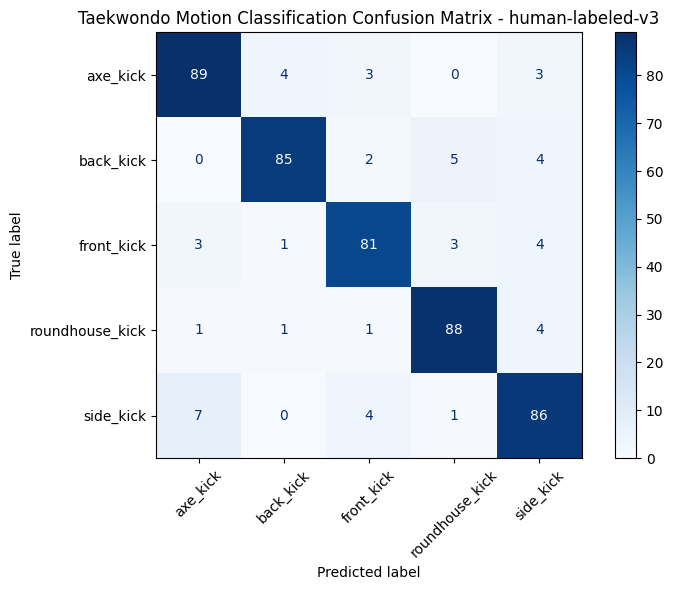


Saved artifacts:
/content/google_drive_jason/MyDrive/taekwondo_model_outputs_human_labeled_v3/taekwondo_motion_classifier_random_forest.joblib
/content/google_drive_jason/MyDrive/taekwondo_model_outputs_human_labeled_v3/taekwondo_label_encoder.joblib
/content/google_drive_jason/MyDrive/taekwondo_model_outputs_human_labeled_v3/taekwondo_feature_columns.json
/content/google_drive_jason/MyDrive/taekwondo_model_outputs_human_labeled_v3/taekwondo_model_summary.json
/content/google_drive_jason/MyDrive/taekwondo_model_outputs_human_labeled_v3/taekwondo_classification_report.txt
/content/google_drive_jason/MyDrive/taekwondo_model_outputs_human_labeled_v3/taekwondo_confusion_matrix.png
/content/google_drive_jason/MyDrive/taekwondo_model_outputs_human_labeled_v3/training_rows_used.csv

human-labeled-v3 training complete
5-fold CV accuracy: 0.89375
Valid samples: 480
Classes: ['axe_kick', 'back_kick', 'front_kick', 'roundhouse_kick', 'side_kick']


In [ ]:
# ============================================================
# Train human-labeled-v3 Random Forest Model
# Cloud-Based Intelligent Taekwondo Motion Classification System
# ============================================================

import os

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

ROOT = "/content/google_drive_jason/MyDrive"

LABEL_TRAIN_PATH = f"{ROOT}/taekwondo_manual_labels_training_valid.csv"

OUT_DIR = f"{ROOT}/taekwondo_model_outputs_human_labeled_v3"
os.makedirs(OUT_DIR, exist_ok=True)

print("Training label file:", LABEL_TRAIN_PATH)
print("Output folder:", OUT_DIR)

df_labels = pd.read_csv(LABEL_TRAIN_PATH)

print("Loaded training labels:", df_labels.shape)
print("\nLabel distribution:")
print(df_labels["manual_label"].value_counts())

# ============================================================
# Fix old Colab Drive paths inside csv_path
# ============================================================

OLD_ROOT = "/content/drive/MyDrive"
NEW_ROOT = "/content/google_drive_jason/MyDrive"

def repair_drive_path(path):
    if not isinstance(path, str):
        return path

    path = path.strip()

    if path.startswith(OLD_ROOT):
        return path.replace(OLD_ROOT, NEW_ROOT, 1)

    return path

df_labels["csv_path"] = df_labels["csv_path"].apply(repair_drive_path)

if "original_video_path" in df_labels.columns:
    df_labels["original_video_path"] = df_labels["original_video_path"].apply(repair_drive_path)

print("\nChecking repaired csv_path examples:")
for p in df_labels["csv_path"].head(5):
    print(os.path.exists(p), p)

missing_csv_count = df_labels["csv_path"].apply(lambda p: not isinstance(p, str) or not os.path.exists(p)).sum()
print("\nMissing CSV after path repair:", missing_csv_count)

valid_labels = [
    "front_kick",
    "roundhouse_kick",
    "side_kick",
    "axe_kick",
    "back_kick",
]

df_labels = df_labels[df_labels["manual_label"].isin(valid_labels)].copy()

print("\nAfter filtering valid labels:", df_labels.shape)
print(df_labels["manual_label"].value_counts())


# ============================================================
# Feature extraction function
# Same style as EC2 app.py
# ============================================================

def extract_features_from_keypoints(df):
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)
    numeric_df = numeric_df.interpolate(limit_direction="both")
    numeric_df = numeric_df.fillna(0)

    features = {}
    features["n_frames"] = len(numeric_df)
    features["n_numeric_cols"] = numeric_df.shape[1]

    for col in numeric_df.columns:
        s = numeric_df[col].astype(float)

        features[f"{col}_mean"] = s.mean()
        features[f"{col}_std"] = s.std()
        features[f"{col}_min"] = s.min()
        features[f"{col}_max"] = s.max()
        features[f"{col}_range"] = s.max() - s.min()
        features[f"{col}_median"] = s.median()

        motion = s.diff().fillna(0).abs()
        features[f"{col}_motion_mean"] = motion.mean()
        features[f"{col}_motion_max"] = motion.max()
        features[f"{col}_motion_std"] = motion.std()

    body_pairs = [
        ("right_foot_index_x", "right_foot_index_y"),
        ("left_foot_index_x", "left_foot_index_y"),
        ("right_ankle_x", "right_ankle_y"),
        ("left_ankle_x", "left_ankle_y"),
        ("right_knee_x", "right_knee_y"),
        ("left_knee_x", "left_knee_y"),
        ("right_wrist_x", "right_wrist_y"),
        ("left_wrist_x", "left_wrist_y"),
        ("right_hip_x", "right_hip_y"),
        ("left_hip_x", "left_hip_y"),
    ]

    for x_col, y_col in body_pairs:
        if x_col in numeric_df.columns and y_col in numeric_df.columns:
            dx = numeric_df[x_col].diff().fillna(0)
            dy = numeric_df[y_col].diff().fillna(0)
            speed = np.sqrt(dx**2 + dy**2)

            part = x_col.replace("_x", "")

            features[f"{part}_speed_mean"] = speed.mean()
            features[f"{part}_speed_max"] = speed.max()
            features[f"{part}_speed_std"] = speed.std()
            features[f"{part}_x_range"] = numeric_df[x_col].max() - numeric_df[x_col].min()
            features[f"{part}_y_range"] = numeric_df[y_col].max() - numeric_df[y_col].min()

    return features


# ============================================================
# Build feature table
# ============================================================

feature_rows = []
labels = []
used_rows = []
skipped_rows = []

for i, row in df_labels.iterrows():
    csv_path = row["csv_path"]
    label = row["manual_label"]
    video_name = row["video_name"]

    if not isinstance(csv_path, str) or not os.path.exists(csv_path):
        skipped_rows.append({
            "video_name": video_name,
            "csv_path": csv_path,
            "reason": "csv_not_found",
        })
        continue

    try:
        df_kp = pd.read_csv(csv_path)
        features = extract_features_from_keypoints(df_kp)

        feature_rows.append(features)
        labels.append(label)

        used_rows.append({
            "video_name": video_name,
            "csv_path": csv_path,
            "manual_label": label,
        })

    except Exception as e:
        skipped_rows.append({
            "video_name": video_name,
            "csv_path": csv_path,
            "reason": str(e),
        })

X = pd.DataFrame(feature_rows)
y = pd.Series(labels, name="label")

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

print("Feature matrix shape:", X.shape)
print("Labels:", y.shape)
print("\nTraining distribution:")
print(y.value_counts())

if skipped_rows:
    df_skipped = pd.DataFrame(skipped_rows)
    skipped_path = os.path.join(OUT_DIR, "skipped_training_rows.csv")
    df_skipped.to_csv(skipped_path, index=False, encoding="utf-8-sig")
    print("\nSkipped rows:", len(df_skipped))
    print("Skipped rows saved:", skipped_path)
else:
    print("\nNo skipped rows.")


# ============================================================
# Train Random Forest with 5-fold CV
# ============================================================

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1,
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

cv_scores = cross_val_score(
    model,
    X,
    y_encoded,
    cv=cv,
    scoring="accuracy",
)

cv_pred = cross_val_predict(
    model,
    X,
    y_encoded,
    cv=cv,
)

cv_accuracy = accuracy_score(y_encoded, cv_pred)

print("\n5-fold CV scores:")
print(cv_scores)

print("\nMean 5-fold CV accuracy:")
print(cv_scores.mean())

print("\nCV prediction accuracy:")
print(cv_accuracy)

print("\nClassification report:")
report_text = classification_report(
    y_encoded,
    cv_pred,
    target_names=encoder.classes_,
)

print(report_text)


# ============================================================
# Fit final model on all valid training data
# ============================================================

model.fit(X, y_encoded)

feature_columns = list(X.columns)

print("\nFinal model trained on all valid samples.")
print("Number of features:", len(feature_columns))


# ============================================================
# Save artifacts
# ============================================================

model_path = os.path.join(OUT_DIR, "taekwondo_motion_classifier_random_forest.joblib")
encoder_path = os.path.join(OUT_DIR, "taekwondo_label_encoder.joblib")
feature_columns_path = os.path.join(OUT_DIR, "taekwondo_feature_columns.json")
summary_path = os.path.join(OUT_DIR, "taekwondo_model_summary.json")
report_path = os.path.join(OUT_DIR, "taekwondo_classification_report.txt")
confusion_matrix_path = os.path.join(OUT_DIR, "taekwondo_confusion_matrix.png")
used_rows_path = os.path.join(OUT_DIR, "training_rows_used.csv")

joblib.dump(model, model_path)
joblib.dump(encoder, encoder_path)

with open(feature_columns_path, "w") as f:
    json.dump(feature_columns, f, indent=2)

with open(report_path, "w") as f:
    f.write(report_text)

df_used = pd.DataFrame(used_rows)
df_used.to_csv(used_rows_path, index=False, encoding="utf-8-sig")

summary = {
    "model_version": "human-labeled-v3",
    "model_type": "RandomForestClassifier",
    "num_samples": int(len(X)),
    "num_classes": int(len(encoder.classes_)),
    "classes": encoder.classes_.tolist(),
    "num_features": int(len(feature_columns)),
    "cv_folds": 5,
    "cv_scores": [float(x) for x in cv_scores],
    "accuracy": float(cv_scores.mean()),
    "cv_prediction_accuracy": float(cv_accuracy),
    "accuracy_note": "This accuracy is based on 5-fold cross-validation using manually labeled v3 training data.",
    "label_source": LABEL_TRAIN_PATH,
    "output_dir": OUT_DIR,
}

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

cm = confusion_matrix(y_encoded, cv_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_,
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Taekwondo Motion Classification Confusion Matrix - human-labeled-v3")
plt.tight_layout()
plt.savefig(confusion_matrix_path, dpi=200)
plt.show()

print("\nSaved artifacts:")
print(model_path)
print(encoder_path)
print(feature_columns_path)
print(summary_path)
print(report_path)
print(confusion_matrix_path)
print(used_rows_path)

print("\n============================================================")
print("human-labeled-v3 training complete")
print("============================================================")
print("5-fold CV accuracy:", cv_scores.mean())
print("Valid samples:", len(X))
print("Classes:", encoder.classes_.tolist())